Trends in Childhood Diarrhea in Kenya (1989–2023)

Introduction.

Diarrhea has long been a critical public health concern in Kenya. It remains one of the leading causes of mortality among children under five, particularly in regions facing water shortages and inadequate sanitation. Beyond immediate health risks, diarrhea contributes to nutritional deficiencies, growth challenges, and places additional strain on already limited primary health care facilities.

This project analyzes trends in childhood diarrhea in Kenya between 1989 and 2023 using Demographic and Health Survey (DHS) data. The goal is to identify changes in prevalence, treatment practices, and feeding behaviors over time, and to generate insights that can inform public health strategies.


Data Set Overview.
The data set was acquired from the Demograpphic and health surveys(DHS) survey data Base. For this analysis, only the essential columns are retained to streamline the workflow and focus on meaningful insights:

- **SurveyYear** → The year the DHS survey was conducted (1989, 1993, 1998, 2003).  
- **Indicator** → Describes what is being measured (e.g., "Children with diarrhea", "Treatment: ORS", "Feeding practices").  
- **Value** → The actual statistic (percentage or count) associated with the indicator.  
- **DenominatorWeighted** → Weighted sample size used to calculate the percentage (accounts for survey design).  
- **DenominatorUnweighted** → Raw number of respondents in the sample (unadjusted).  
- **CharacteristicLabel** → Subgroup category (e.g., "Total", "Urban", "Rural").  
- **ByVariableLabel** → Additional context for the indicator (e.g., "Three years preceding survey", "Five years preceding survey").

These columns provide the foundation for analyzing trends, comparing practices, and identifying gaps. All other metadata columns (IDs, codes, internal DHS references) are dropped to keep the dataset clean and analysis-ready.



Objectives of the Analysis

This notebook aims to achieve the following objectives:

1.Examine diarrhea prevalence trends 
   - Assess changes in childhood diarrhea prevalence in Kenya over time.  
   - Relate observed patterns to public health interventions and environmental health determinants.

2.Analyze ORS usage trends
   - Investigate adoption of Oral Rehydration Solution (ORS) across survey years.  
   - Identify peaks and declines, and connect them to caregiver practices, health campaigns, and supply factors.

3.Compare diarrhea prevalence with ORS usage 
   - Explore correlations between disease burden and treatment adoption.  
   - Test the hypothesis that reduced ORS usage may reflect fewer diarrhea cases due to improved WASH standards.

4.Evaluate feeding practices – fluids 
   - Assess caregiver behaviors in fluid intake during diarrhea episodes.  
   - Distinguish recommended practices (increased fluids) from risky practices (decreased fluids).  
   - Link findings to water access, sanitation, and caregiver education.

Data Loading and Cleaning

In [41]:

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('diarrhea_national_ken.csv')
# Keep only preferred/official DHS figures
data = data[data['IsPreferred'] == 1]


In [42]:
#Get an overview of the dataset
print(data.head())
print(data.info())
print(data.describe())
#Check the length of the dataset
print(f'The dataset contains {len(data)} records.')
#Keeping only relevant columns for analysis
data = data[["SurveyYear", "Indicator", "Value", 
         "DenominatorWeighted", "DenominatorUnweighted", 
         "CharacteristicLabel", "ByVariableLabel", "IsPreferred"]]


print()

  ISO3  DataId                                          Indicator   Value  \
1  KEN  391160                             Children with diarrhea    12.7   
3  KEN  398677  Number of children born in the last five (or t...  6589.0   
5  KEN  341587  Number of children born in the last five (or t...  6407.0   
7  KEN  463848  Feeding practices during diarrhea: Increased a...    28.7   
9  KEN  463854  Feeding practices during diarrhea: Same amount...    71.3   

   Precision DHS_CountryCode CountryName  SurveyYear   SurveyId  \
1          1              KE       Kenya        1989  KE1989DHS   
3          0              KE       Kenya        1989  KE1989DHS   
5          0              KE       Kenya        1989  KE1989DHS   
7          1              KE       Kenya        1989  KE1989DHS   
9          1              KE       Kenya        1989  KE1989DHS   

     IndicatorId  ...  IsPreferred       SDRID  RegionId  SurveyYearLabel  \
1  CH_DIAR_C_DIA  ...            1  CHDIARCDIA       NaN 

Data Cleaning

In [43]:
#display of the remaining relevant columns
print(data.head())
#checking for missing values
print(data.isnull().sum())
# Confirm missing denominators only appear in non-essential rows
print(data[data['DenominatorWeighted'].isnull()]['Indicator'].unique())
print()

   SurveyYear                                          Indicator   Value  \
1        1989                             Children with diarrhea    12.7   
3        1989  Number of children born in the last five (or t...  6589.0   
5        1989  Number of children born in the last five (or t...  6407.0   
7        1989  Feeding practices during diarrhea: Increased a...    28.7   
9        1989  Feeding practices during diarrhea: Same amount...    71.3   

   DenominatorWeighted  DenominatorUnweighted CharacteristicLabel  \
1               6589.0                 6407.0               Total   
3                  NaN                 6407.0               Total   
5               6589.0                    NaN               Total   
7                838.0                  833.0               Total   
9                838.0                  833.0               Total   

                   ByVariableLabel  IsPreferred  
1  Five years preceding the survey            1  
3  Five years preceding the 

Column Renaming

To improve readability and consistency in the dataset, I renamed several columns. This step makes it easier to reference them in code and ensures a clean, professional structure for analysis. For example, `SurveyYear` was shortened to `Year`, and multi-word names such as `DenominatorWeighted` were reformatted to `Denominator_Weighted` using underscores. This improves clarity and reduces the chance of errors when writing code.



In [44]:
#Data Cleaning with data wrangling techniques
#Renaming columns for better readability
data.rename(columns={
    "SurveyYear": "Year",
    "Indicator": "Indicator",
    "Value": "Value",
    "DenominatorWeighted": "Denominator_Weighted",
    "DenominatorUnweighted": "Denominator_Unweighted",
    "CharacteristicLabel": "Characteristic_Label",
    "ByVariableLabel": "By_Variable_Label"
}, inplace=True)

## Handling Missing Values

During data preparation, I identified missing values in the denominator columns:
- Denominator_Weighted → 49 missing
- Denominator_Unweighted → 46 missing

Since the main focus of this notebook is on trends in percentages (Value) across survey years, the denominators are supporting information rather than the core variable. The missing values do not affect the calculation or interpretation of prevalence and treatment percentages, which are already provided in the dataset. For this reason, I have chosen to ignore the missing denominators in this Notebook( Trends in Childhood Diarrhoea in Kenya 1989-2003). This decision keeps the dataset intact for trend analysis, while acknowledging that denominators may be revisited in later notebooks where reliability checks or predictive modeling are required.

Trend 1 : The Prevalance of Diarrhoea in Kenya 1989-2023

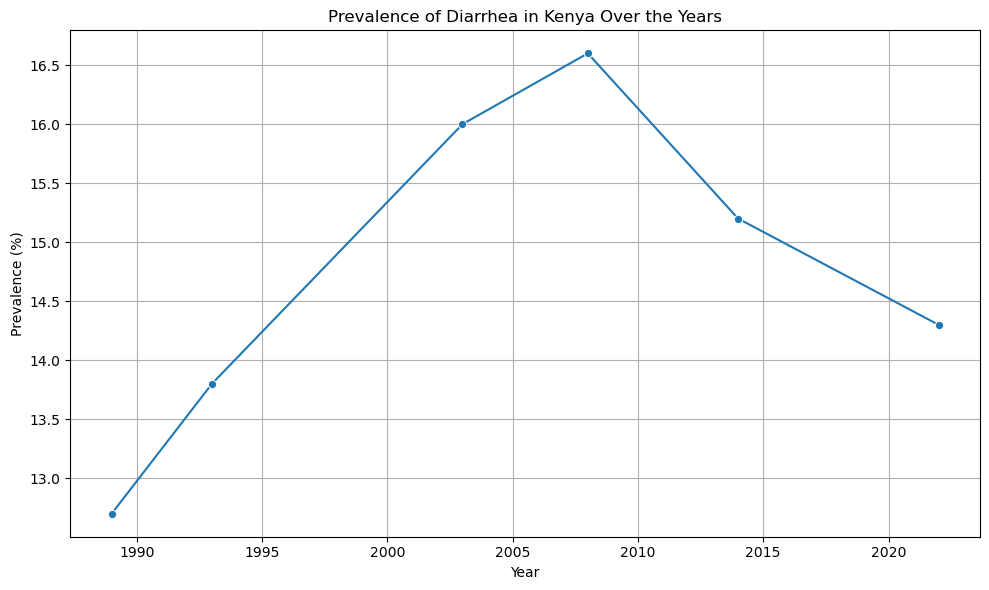

     Year  Value
1    1989   12.7
27   1993   13.8
115  2003   16.0
191  2008   16.6
278  2014   15.2
366  2022   14.3


In [45]:
#the prevalence of diarrhea in Kenya over the years
diarrhea_trends = data[data['Indicator'] == 'Children with diarrhea']

plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='Value', data=diarrhea_trends, marker='o')
plt.title('Prevalence of Diarrhea in Kenya Over the Years')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.grid(True)
plt.tight_layout()
plt.savefig('diarrhea_prevalence_trend.png', dpi=150)
plt.show()

# Print actual values for your written analysis
print(diarrhea_trends[['Year', 'Value']].sort_values('Year'))

Trend Analysis: Prevalence of Childhood Diarrhea in Kenya (1989–2023)

The line graph shows how the prevalence of diarrhea among children under five in Kenya has changed over time. From the early 1990s, prevalence rose from 12.7% to a peak of 16.7% in 2006, before beginning to decline to 14.3% by 2022. This pattern reflects both the persistent challenges of water scarcity, sanitation, and hygiene, as well as the gradual impact of public health interventions such as oral rehydration therapy (ORS) promotion and community health education.

As an environmental health concern, diarrhea is closely linked to access to safe water, food hygiene, and household sanitation. The upward trend in the 1990s highlights the strain on primary health care facilities and the vulnerability of children in regions with limited infrastructure. The decline after 2003 suggests that increased awareness, improved treatment practices, and expansion of health programs began to reduce the burden.

This analysis underscores the importance of sustained investment in water, sanitation, and hygiene (WASH) programs, alongside strengthening health systems, to prevent diarrhea-related morbidity and mortality among Kenyan children.

Key Insight: Diarrhea prevalence increased in the 1990s but declined after 2003, reflecting both challenges and progress in Kenya’s public health response.

Trend 2: ORS Usage

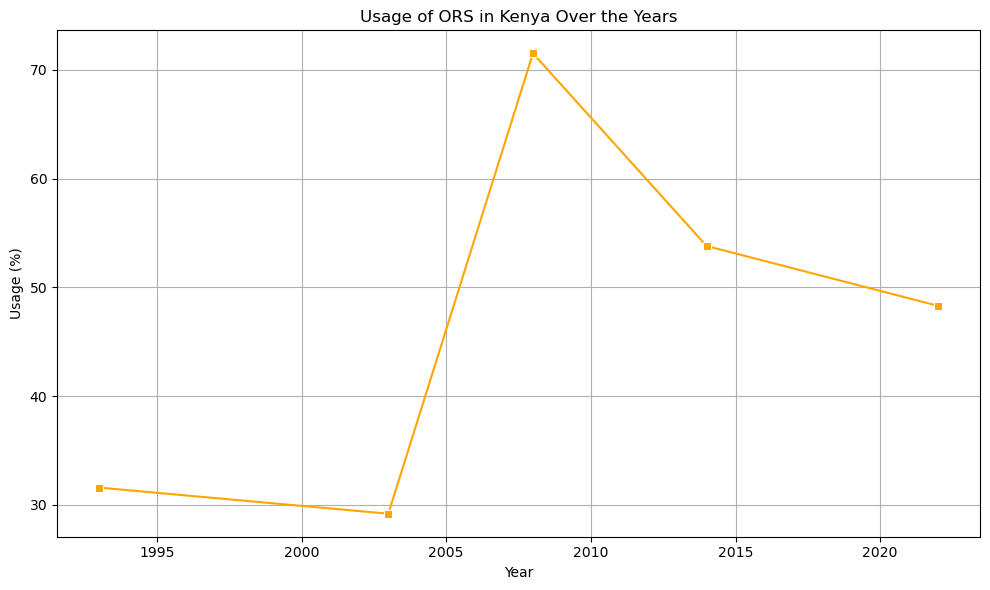

     Year  Value
37   1993   31.6
123  2003   29.2
201  2008   71.5
288  2014   53.8
374  2022   48.3


In [46]:
#usage of ORS
ors_usage = data[data['Indicator'] == 'Treatment of diarrhea: Oral rehydration solution (ORS)']

plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='Value', data=ors_usage, marker='s', color='orange')
plt.title('Usage of ORS in Kenya Over the Years')
plt.xlabel('Year')
plt.ylabel('Usage (%)')
plt.grid(True)
plt.tight_layout()
plt.savefig('ors_usage_trend.png', dpi=150)
plt.show()

# Print actual values
print(ors_usage[['Year', 'Value']].sort_values('Year'))

Trend Analysis: ORS Usage in Kenya (1993–2023)

The graph illustrates the adoption of Oral Rehydration Solution (ORS) in Kenya over time. ORS usage began at relatively low levels(31%) in the early 1990s, fluctuated through the late 1990s and early 2000s, and then rose sharply around 2009 upto 71% usage. However, this peak was followed by a decline in subsequent years to 52% by the year 2014, with usage stabilizing at lower levels of 48% by 2020.

From an environmental health standpoint, these fluctuations highlight both progress and persistent challenges. The sharp increase reflects successful public health campaigns and improved awareness of ORS as a lifesaving intervention. The later decline suggests gaps in sustained health education, supply chain issues, or competing treatment practices. 

This trend emphasizes the need for consistent investment in community health education, reliable distribution of ORS, and integration of water, sanitation, and hygiene (WASH) programs. Sustaining high ORS usage is critical to reducing child mortality from diarrhea and ensuring resilience in primary health care systems.

Combining the two Trends in one plot for a better comparison

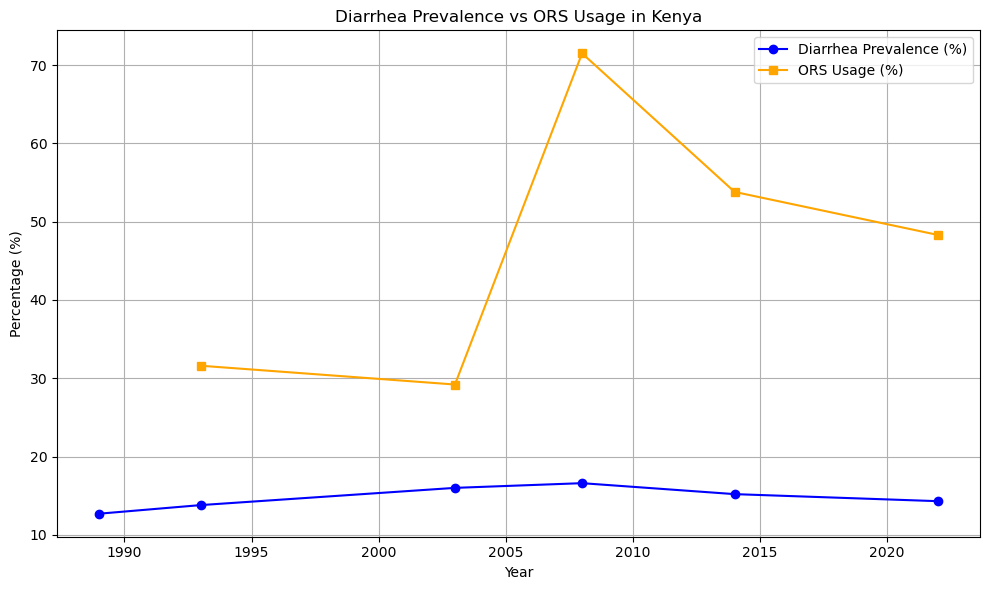

In [47]:
#combining the two trends in one plot for better comparison
import matplotlib.pyplot as plt

# Filter datasets
diarrhea_trends = data[data['Indicator'] == 'Children with diarrhea']
ors_trends = data[data['Indicator'] == 'Treatment of diarrhea: Oral rehydration solution (ORS)']

plt.figure(figsize=(10,6))
plt.plot(diarrhea_trends['Year'], diarrhea_trends['Value'], 
         marker='o', color='blue', label='Diarrhea Prevalence (%)')
plt.plot(ors_trends['Year'], ors_trends['Value'], 
         marker='s', color='orange', label='ORS Usage (%)')

plt.title('Diarrhea Prevalence vs ORS Usage in Kenya')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('prevalence_vs_ors.png', dpi=150)
plt.show()

Comparative Analysis: Diarrhea Prevalence vs ORS Usage

The combined graph allows us to compare diarrhea prevalence and ORS usage in Kenya over time. Diarrhea prevalence remained relatively stable between 13% and 18%% across the survey years, while ORS usage showed much greater fluctuation — peaking sharply around 2008 and then declining through 2020.

From an environmental health perspective, this pattern suggests that ORS usage is not solely driven by prevalence. The sharp rise in ORS adoption likely reflects intensive public health campaigns and improved availability during the late 2000s. The subsequent decline could have multiple explanations:
- Reduced demand: If diarrhea prevalence was falling due to improved water, sanitation, and hygiene (WASH) standards, fewer children required ORS treatment.
- Programmatic gaps: Declines may also reflect reduced intensity of health education campaigns, supply chain challenges, or shifts toward alternative treatments.
- Disconnect between knowledge and practice: Awareness of ORS may remain high, but consistent usage depends on sustained reinforcement and access.

This comparative view strengthens the analysis by showing that treatment statistics must be interpreted alongside disease burden. It highlights the importance of upstream interventions — clean water, sanitation, and hygiene — in reducing diarrhea incidence, while also emphasizing the need for continuous investment in ORS promotion to prevent child mortality when cases do occur.

Feeding Practices: Fluids

Diarrhea management in children under five is not only about treatment but also about supportive care. One critical aspect is fluid intake, which prevents dehydration and reduces mortality risk. The DHS data provides insights into how caregivers in Kenya have managed fluid feeding practices during diarrhea episodes over the years.
This section focuses on:
- Trends in fluid intake among children with diarrhea.
- Comparisons across survey years to assess whether public health messages on hydration have been effective.
- Environmental health implications, since access to safe water directly influences the ability of households to provide adequate fluids.

By analyzing these patterns, we can evaluate progress in caregiver practices and identify gaps where further education and WASH interventions are needed.

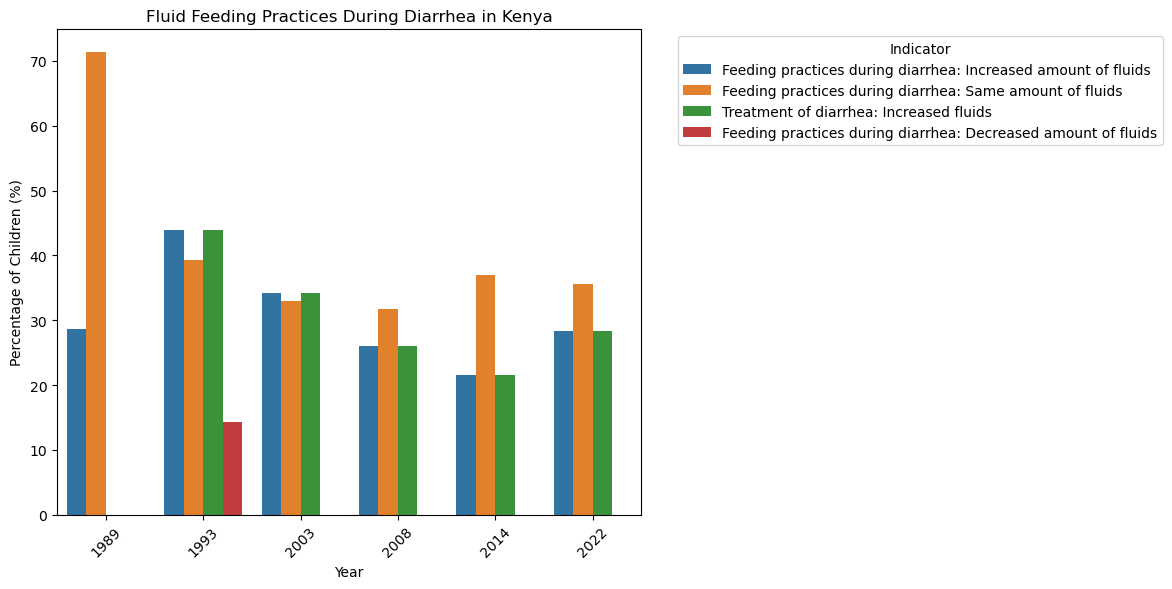

In [48]:
#filter the dataset for fluid intake during diarrhea episodes
fluids_indicators = [
    "Feeding practices during diarrhea: Same amount of fluids",
    "Feeding practices during diarrhea: Increased amount of fluids",
    "Treatment of diarrhea: Increased fluids",
    "Feeding practices during diarrhea: Decreased amount of fluids"
]

fluids_trends = data[data['Indicator'].isin(fluids_indicators)]

plt.figure(figsize=(12,6))
sns.barplot(x="Year", y="Value", hue="Indicator", data=fluids_trends)
plt.title("Fluid Feeding Practices During Diarrhea in Kenya")
plt.xlabel("Year")
plt.ylabel("Percentage of Children (%)")
plt.legend(title="Indicator", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fluid_practices.png', dpi=150)
plt.show()

Why a Bar Chart?

While line graphs are useful for showing overall trends, they can become cluttered when comparing multiple overlapping practices. In the case of fluid feeding practices, a grouped bar chart is preferred because it:
- Clearly separates each practice within the same survey year.
- Makes differences between categories (e.g., increased vs decreased fluids) easy to see.
- Highlights the relative dominance of recommended practices compared to risky ones.
- Provides a straightforward snapshot of caregiver behavior at each point in time.
This visualization choice improves clarity and ensures that comparisons are not lost in overlapping lines.

Interpretation of Fluid Feeding Practices
The bar chart shows how caregivers in Kenya managed fluid intake during childhood diarrhea episodes across different years:
- Increased fluids (blue): Adoption of the recommended practice has varied, with notable improvements in some years but not consistently sustained.
- Same amount of fluids (orange): A significant proportion of caregivers continue to give the usual amount, which is better than reducing fluids but still below best practice.
- Treatment: Increased fluids (green): This indicator peaked around the late 1990s, reflecting strong health messaging, but declined afterward.
- Decreased fluids (red): Although consistently low, this dangerous practice persists, highlighting gaps in caregiver knowledge and water access.

From an environmental health perspective, these practices are shaped by water availability, sanitation infrastructure, and caregiver education. The data suggests that while public health campaigns have influenced behavior, sustained reinforcement and reliable access to safe fluids remain essential. Strengthening WASH programs and caregiver training is critical to ensure that the recommended practice of increasing fluids becomes the consistent norm.

Summary and Conclusion

This analysis set out to examine childhood diarrhea trends in Kenya, focusing on prevalence, treatment practices, and caregiver feeding behaviors. The objectives were to:  
1. Assess changes in diarrhea prevalence over time.  
2. Analyze adoption of Oral Rehydration Solution (ORS).  
3. Compare diarrhea prevalence with ORS usage to explore correlations.  
4. Evaluate fluid feeding practices during diarrhea episodes.

Key findings include:  
- Diarrhea prevalence showed fluctuations across survey years, reflecting both disease burden and the impact of public health interventions.  
- ORS usage peaked during periods of strong health campaigns but declined afterward, suggesting challenges in sustaining caregiver adoption and treatment supply.  
- Comparative analysis indicated that reduced ORS usage may partly reflect fewer diarrhea cases due to improved WASH standards, though gaps in education and supply chains remain influential.  
- Fluid feeding practices revealed mixed caregiver behaviors: while increased fluids (recommended) were adopted in some years, many caregivers maintained the same amount, and a small proportion still decreased fluids — a dangerous practice that persists.

Overall, the findings highlight the importance of sustained WASH interventions, continuous caregiver education, and reliable treatment supply. Strengthening these areas is critical to reducing childhood diarrhea burden and ensuring that recommended practices become the consistent norm in Kenyan households.